<a href="https://colab.research.google.com/github/elnazshokrollahi/ai-ml-refresh-journey/blob/main/phase-3-ml-classic/phase-3-ml-classic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pytorch - Lesson 1: Tensors and Basics

In [ ]:
import torch
import torch.nn as nn
import numpy as np

print(torch.__version__)

2.10.0+cu128


In [ ]:
t1 = torch.tensor([1,2,3,4,5])
t2 = torch.tensor([[1,2,3],[4,5,6]])

print(t1.shape)
print(t2.shape)
print(t1.dtype)

torch.Size([5])
torch.Size([2, 3])
torch.int64


In [ ]:
arr = np.array([1,2,3])
t = torch.from_numpy(arr)

print(arr)
print(t)

arr_back = t.numpy()

print(arr_back)

[1 2 3]
tensor([1, 2, 3])
[1 2 3]


In [ ]:
zeros = torch.zeros(3,4)
ones = torch.ones(2,3)

rand = torch.rand(3,3)
randn = torch.randn(3,3)

t = torch.arange(0,10,2)

In [ ]:
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print(a+b)
print(a*b)
print(a@b)
print(torch.sqrt(a))

t = torch.arange(12)
print(t)
t1 = t.reshape(3,4)
print(t1)
t2 = t1.flatten()
print(t2)

tensor([5., 7., 9.])
tensor([ 4., 10., 18.])
tensor(32.)
tensor([1.0000, 1.4142, 1.7321])
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])


In [ ]:
device  = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using: {device}")

t =torch.randn(3,3).to(device)
print(t)


Using: cuda
tensor([[-0.3432,  0.3922, -0.7609],
        [ 0.7535,  0.4925,  0.1874],
        [-0.8783,  1.0283, -1.2256]], device='cuda:0')


In [ ]:
x = torch.tensor(3.0, requires_grad=True)

y = x ** 2 + 2 * x + 1
y.backward()

print(x.grad)

tensor(8.)


In [ ]:
# Exercise 1:

#Create a 4x4 tensor of random numbers
#Print its shape and dtype
#Multiply it by 2
#Reshape to (2, 8)

In [ ]:
t = torch.randn(4,4)
print (t)

print(t.shape)
print(t.dtype)
t2 = t * 2
print(t2)

t_reshape = torch.reshape(t, (2,8))
print(t_reshape)

tensor([[-0.1287,  1.5611, -0.3484, -0.1162],
        [-0.1538,  0.7924,  0.3155, -0.0327],
        [-0.6536, -0.4880, -1.3962,  1.5505],
        [-0.2523,  0.4095,  0.3993, -0.1212]])
torch.Size([4, 4])
torch.float32
tensor([[-0.2573,  3.1223, -0.6969, -0.2324],
        [-0.3076,  1.5847,  0.6310, -0.0654],
        [-1.3071, -0.9761, -2.7925,  3.1010],
        [-0.5046,  0.8191,  0.7985, -0.2424]])
tensor([[-0.1287,  1.5611, -0.3484, -0.1162, -0.1538,  0.7924,  0.3155, -0.0327],
        [-0.6536, -0.4880, -1.3962,  1.5505, -0.2523,  0.4095,  0.3993, -0.1212]])


In [ ]:
#Exercise 2 — Operations:
a = torch.tensor([2.0, 4.0, 6.0, 8.0])
b = torch.tensor([1.0, 3.0, 5.0, 7.0])

#Add, multiply, and compute dot product
#Print the mean and max of a

added = a + b
multipled = a * b
dotted = a @ b

print(torch.mean(a))
print(torch.max(a))

AttributeError: 'Tensor' object has no attribute 'b'

In [ ]:
#Exercise 3 — Gradients:

#Create a tensor x = 4.0 with requires_grad=True
#Compute y = 3x² + 2x + 5
#Call y.backward()
#Print the gradient — what do you expect it to be?
#Hint: derivative of 3x² + 2x + 5 is 6x + 2

x = torch.tensor(4.0, requires_grad= True )
y = 3 * x **2 + 2 * x + 5

y.backward()

print(x.grad)



tensor(26.)


# First Neural net in PyTorch

In [ ]:
import torch
import torch.nn as nn

class MyFirstNet (nn.Module):
  def __init__(self):
    super().__init__()

    self.layer1 = nn.Linear(2,4)
    self.layer2 = nn.Linear(4,1)

  def forward(self, x):

    x = self.layer1(x)
    x = torch.relu(x)
    x = self.layer2(x)

    return x

model = MyFirstNet()

print(model)

MyFirstNet(
  (layer1): Linear(in_features=2, out_features=4, bias=True)
  (layer2): Linear(in_features=4, out_features=1, bias=True)
)


In [ ]:
#Exercise 1 — Build a network:
#Build a neural network called PatientNet that:

#Takes 3 inputs (age, risk score, blood pressure)
#Has a hidden layer with 8 neurons
#Has a second hidden layer with 4 neurons
#Outputs 1 value (disease prediction)
#Uses ReLU activation between layers
#Print model architecture

In [ ]:
import torch
import torch.nn as nn

class PatientNet (nn.Module):
  def __init__(self):
    super().__init__()

    self.layer1 = nn.Linear (3,8)
    self.layer2 = nn.Linear (8,4)
    self.layer3 = nn.Linear (4,1)

  def forward (self, x):

    x = self.layer1(x)
    x = torch.relu(x)
    x = self.layer2 (x)
    x = torch.relu(x)
    x = self.layer3(x)
    return x


model = PatientNet ()

print (model)

PatientNet(
  (layer1): Linear(in_features=3, out_features=8, bias=True)
  (layer2): Linear(in_features=8, out_features=4, bias=True)
  (layer3): Linear(in_features=4, out_features=1, bias=True)
)


In [ ]:
#Exercise 2 — Forward pass:
#Create some fake patient data:
X = torch.tensor([[45, 0.7, 120],
                   [32, 0.3, 110],
                   [67, 0.9, 140]], dtype=torch.float32)
#Pass it through your PatientNet and print the output shape.
print(X)

predictions = model (X)
print (predictions)
print(predictions.shape)


tensor([[ 45.0000,   0.7000, 120.0000],
        [ 32.0000,   0.3000, 110.0000],
        [ 67.0000,   0.9000, 140.0000]])
tensor([[-0.0446],
        [-0.0446],
        [-0.0446]], grad_fn=<AddmmBackward0>)
torch.Size([3, 1])


In [ ]:
#Exercise 3 — Training loop:
#Train PatientNet on this data:
X = torch.tensor([[25, 0.2, 110], [45, 0.5, 120], [67, 0.85, 140],
                   [32, 0.3, 115], [61, 0.75, 135], [28, 0.25, 108]],
                   dtype=torch.float32)
y = torch.tensor([[0], [0], [1], [0], [1], [0]], dtype=torch.float32)

#Use Adam optimizer with lr=0.01
#Train for 100 epochs
#Print loss every 10 epochs
#Is the loss going down?

import torch.optim as optim
model = PatientNet ()
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range (100):


  predictions = model (X)
  loss = loss_fn (predictions, y)

  loss.backward()

  optimizer.step()

  optimizer.zero_grad()

  if epoch % 10 == 0:
    print(f"Epoch {epoch}: Loss = {loss.item():.4f}")


Epoch 0: Loss = 1.3476
Epoch 10: Loss = 0.7647
Epoch 20: Loss = 0.5776
Epoch 30: Loss = 0.4442
Epoch 40: Loss = 0.2932
Epoch 50: Loss = 0.1653
Epoch 60: Loss = 0.0965
Epoch 70: Loss = 0.0602
Epoch 80: Loss = 0.0401
Epoch 90: Loss = 0.0283


## Making Predictions and Evaluating the Neural Networks

In [ ]:
new_patients = torch.tensor([[50, 0.8, 135],[30, 0.2, 110]], dtype=torch.float32)
print(new_patients)

tensor([[ 50.0000,   0.8000, 135.0000],
        [ 30.0000,   0.2000, 110.0000]])


In [ ]:
model.eval()

with torch.no_grad():
  predictions = model(new_patients)
  probabilities = torch.sigmoid(predictions)
  labels = (probabilities >= 0.5).float()

print (probabilities)
print(labels)

tensor([[0.0381],
        [0.0009]])
tensor([[0.],
        [0.]])


# # Everything together



In [ ]:
#building the model

import torch
import torch.nn as nn

class PatientNet (nn.Module):

  def __init__(self):
    super().__init__()

    self.layer1 = nn.Linear(3,8)
    self.layer2 = nn.Linear(8,4)
    self.layer3 = nn.Linear (4,1)

  def forward(self,x):
    x = self.layer1(x)
    x = torch.relu(x)
    x = self.layer2(x)
    x = torch.relu(x)
    x = self.layer3(x)
    return x

  model = PatientNet()
  print (model)

PatientNet(
  (layer1): Linear(in_features=3, out_features=8, bias=True)
  (layer2): Linear(in_features=8, out_features=4, bias=True)
  (layer3): Linear(in_features=4, out_features=1, bias=True)
)


In [ ]:
# defining the training and testing inputs and outputs
X = torch.tensor([[25, 0.2, 110], [45, 0.5, 120], [67, 0.85, 140],
                   [32, 0.3, 115], [61, 0.75, 135], [28, 0.25, 108]],
                   dtype=torch.float32)
y = torch.tensor ([[0], [0], [1], [0], [1], [0]], dtype= torch.float32)
from sklearn.model_selection import train_test_split

X_np = X.numpy()
y_np = y.numpy()

X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size =0.2, random_state =42)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype =torch.float32)
X_test = torch.tensor(X_test, dtype =torch.float32)
y_test = torch.tensor(y_test, dtype =torch.float32)



Epoch 0: Loss = 1.8504
Epoch 20: Loss = 0.7072
Epoch 40: Loss = 0.6410
Epoch 60: Loss = 0.5281
Epoch 80: Loss = 0.4098
Epoch 100: Loss = 0.3136
Epoch 120: Loss = 0.2471
Epoch 140: Loss = 0.1962
Epoch 160: Loss = 0.1507
Epoch 180: Loss = 0.1044
Epoch 200: Loss = 0.0609
Epoch 220: Loss = 0.0317
Epoch 240: Loss = 0.0178
Epoch 260: Loss = 0.0114
Epoch 280: Loss = 0.0081
Epoch 300: Loss = 0.0062
Epoch 320: Loss = 0.0049
Epoch 340: Loss = 0.0040
Epoch 360: Loss = 0.0034
Epoch 380: Loss = 0.0029
Epoch 400: Loss = 0.0025
Epoch 420: Loss = 0.0022
Epoch 440: Loss = 0.0019
Epoch 460: Loss = 0.0017
Epoch 480: Loss = 0.0016
Epoch 500: Loss = 0.0014
Epoch 520: Loss = 0.0013
Epoch 540: Loss = 0.0012
Epoch 560: Loss = 0.0011
Epoch 580: Loss = 0.0010
Epoch 600: Loss = 0.0009
Epoch 620: Loss = 0.0008
Epoch 640: Loss = 0.0008
Epoch 660: Loss = 0.0007
Epoch 680: Loss = 0.0007
Epoch 700: Loss = 0.0006
Epoch 720: Loss = 0.0006
Epoch 740: Loss = 0.0006
Epoch 760: Loss = 0.0005
Epoch 780: Loss = 0.0005
Epoch 

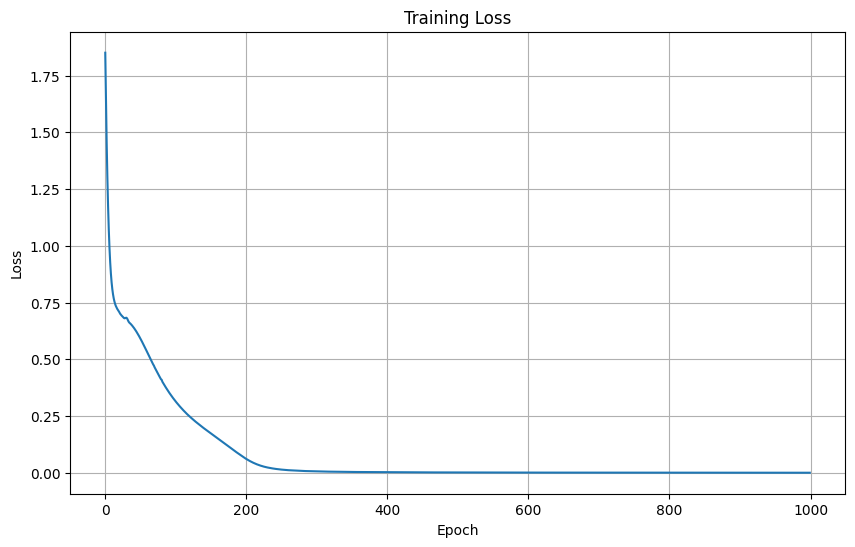

In [ ]:
#training the model

import torch.optim as optim
import matplotlib.pyplot as plt

losses = []
model = PatientNet()
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam (model.parameters() ,lr=0.01)

model.train()

for epoch in range (1000):
  predictions = model(X_train)
  loss = loss_fn(predictions, y_train)
  loss.backward()
  optimizer.step()
  optimizer.zero_grad()
  losses.append(loss.item())

  if epoch %20 == 0:
    print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

#plot
plt.figure(figsize=(10,6))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [ ]:
#test the model

model.eval()

with torch.no_grad():
  test_predictions = model(X_test)
  test_probs = torch.sigmoid(test_predictions)
  test_labels = (test_probs >=0.5).float()

  correct = (test_labels == y_test).float().sum()
  accuracy = correct / len(y_test)
  print(f"Test Accuracy:{accuracy:.0%}")


Test Accuracy:50%


In [ ]:
#Exercise 1 — Predict new patients:
#Using your trained PatientNet, predict whether these patients have the disease:
new_patients = torch.tensor([
    [55, 0.82, 138],   # older, high risk
    [28, 0.15, 108],   # young, low risk
    [48, 0.61, 125],   # middle aged, medium risk
], dtype=torch.float32)
#Print probability and final label for each.

model.eval()

with torch.no_grad():
  newPat_pred = model(new_patients)
  newPat_prob = torch.sigmoid(newPat_pred)
  newPat_labels = (newPat_prob >=0.5).float()

  print(newPat_prob)
  print(newPat_labels)

tensor([[9.9737e-01],
        [3.7794e-04],
        [9.8344e-01]])
tensor([[1.],
        [0.],
        [1.]])


In [ ]:
#Exercise 2 — Plot loss curve:
#Retrain your model but store the loss each epoch. Plot the loss curve. Does it look healthy?


In [ ]:
#Exercise 3 — Train/test split:
#Split your data into train and test sets. Train on train set, evaluate on test set. Print test accuracy.

# Droupout and Batch Normalization

In [ ]:

class PatientNet(nn.Module):

  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear (3,8)
    self.bn1 = nn.BatchNorm1d(8)
    self.dropout1 = nn.Dropout(0.3)

    self.layer2 = nn.Linear(8,4)
    self.bn2 = nn.BatchNorm1d(4)
    self.dropout2 = nn.Dropout(0.3)

    self.layer3 = nn.Linear(4,1)


  def forward(self,x):
    x = self.layer1(x)
    x = self.bn1(x)
    x = torch.relu(x)
    x = self.dropout1(x)

    x = self.layer2(x)
    x = self.bn2(x)
    x = torch.relu(x)
    x = self.dropout2(x)

    x = self.layer3(x)
    return x



Epoch 0: Loss = 0.7880
Epoch 50: Loss = 0.2062
Epoch 100: Loss = 0.4674
Epoch 150: Loss = 0.2969
Epoch 200: Loss = 0.1801
Epoch 250: Loss = 0.0842
Epoch 300: Loss = 0.0582
Epoch 350: Loss = 0.0123
Epoch 400: Loss = 0.1222
Epoch 450: Loss = 0.0028


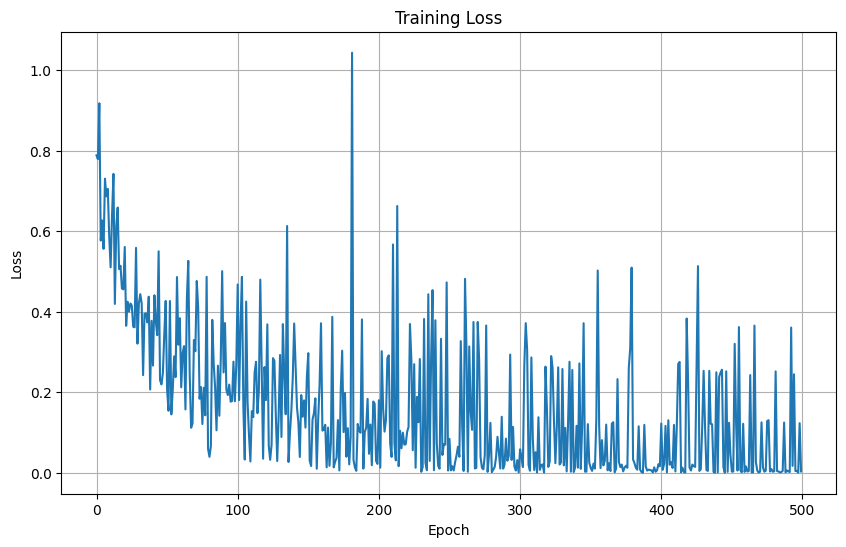

In [ ]:
#training the model

import torch.optim as optim
import matplotlib.pyplot as plt

losses = []
model = PatientNet()
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam (model.parameters() ,lr=0.01)

model.train()

for epoch in range (500):
  predictions = model(X_train)
  loss = loss_fn(predictions, y_train)
  loss.backward()
  optimizer.step()
  optimizer.zero_grad()
  losses.append(loss.item())

  if epoch %50 == 0:
    print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

#plot
plt.figure(figsize=(10,6))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [ ]:
model.eval()

with torch.no_grad():
  test_predictions = model(X_test)
  test_probs = torch.sigmoid(test_predictions)
  test_labels = (test_probs >=0.5).float()

  correct = (test_labels == y_test).float().sum()
  accuracy = correct / len(y_test)
  print(f"Test Accuracy:{accuracy:.0%}")

Test Accuracy:50%


In [ ]:
torch.save(model.state_dict(), "patient_net.pth")
print("Model Saved!")

Model Saved!


In [ ]:
loaded_model = PatientNet()

loaded_model.load_state_dict(torch.load("patient_net.pth"))

loaded_model.eval()

print("Model Loaded!")

Model Loaded!


In [ ]:
with torch.no_grad():
  new_patient = torch.tensor([[55, 0.82, 138]], dtype = torch.float32)
  loaded_pred = loaded_model (new_patient)
  probability = torch.sigmoid(loaded_pred)
  print(f"Disease probability: {probability.item(): .0%}")

Disease probability:  88%


In [ ]:
with torch.no_grad():
  original_pred = torch.sigmoid(model(new_patient))

In [ ]:
print ("Original:", original_pred)
print ("Loaded:", probability)
print("match:", torch.allclose(original_pred, probability))

Original: tensor([[0.8834]])
Loaded: tensor([[0.8834]])
match: True


In [ ]:
torch.save (model, "patient_net_full.pth")

saved_model = torch.load("patient_net_full.pth", weights_only = False)
saved_model.eval()

PatientNet(
  (layer1): Linear(in_features=3, out_features=8, bias=True)
  (bn1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (layer2): Linear(in_features=8, out_features=4, bias=True)
  (bn2): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (layer3): Linear(in_features=4, out_features=1, bias=True)
)

## Pretrained , transfer Learning

In [ ]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(pretrained = True)
print(model)



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Freeze all pretrained layers
#Scenario 1 when the dataset is too small ..
# Use Feature extraction

for param in model.parameters():
  param.requires_grad = False


# replace the final layer with YOUR task
# ResNet18 final layer: Linear(512, 1000) → 1000 classes
# Your task: 2 classes (disease/healthy)

model.fc = nn.Linear(512,2)

#count trainable parameters

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"Trainable: {trainable:,}")
print(f"total: {total:,}")
print(f"Training: {trainable/total: .2%} of all parameters")


Trainable: 1,026
total: 11,177,538
Training:  0.01% of all parameters


In [ ]:
# scenario 2
# medium size data
# use Fine Tuning later layers

for name, param in model.named_parameters():
  if 'layer1' in name or 'layer2' in name:
    param.requires_grad = False

model.fc = nn.Linear(512, 2)

